# Lernnavi — Fairness Audit on a Dropout Prediction Model

**Ethical question**
> If a school deploys a dropout prediction model trained on first-week platform behaviour
> to allocate learning support, does that model produce asymmetric errors across
> student **gender** and **school track** (Gymnasium vs. Vocational)?

**Why this question matters**
Dropout prediction is a high-stakes use case: a false positive restricts a student's
autonomy, a false negative denies them support. If error rates differ by protected group,
the intervention policy is inequitable — even if the model is globally accurate.

**Fairness framework (EPFL MLBD course)**
Demographic Parity · Equalized Odds · Predictive Value Parity · Impossibility Result · TreeSHAP


## Setup

Standard imports. We install `shap` if not already present.


In [2]:
import subprocess, sys, json, warnings
subprocess.run([sys.executable, "-m", "pip", "install", "shap", "--quiet"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import shap

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.grid': True,
                     'axes.facecolor': '#f8f9fa', 'grid.color': 'white'})

DATA_DIR = r'C:\Users\thyba\Downloads'


C:\Users\thyba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Build the dropout dataset

We construct one row per student using only **week-0 behaviour** (the first 7 days on the platform).

**Features (all from week 0 only):**
- `n_tasks` — number of exercises attempted
- `avg_score` — mean correctness score (CORRECT=1, PARTIAL=0.5, WRONG=0)
- `avg_diff` — mean difficulty of assigned exercises (set by the adaptive algorithm, not the student)

**Outcome (dropout label):**
A student is labelled *dropout* if they left the platform before week 3 (i.e. used it fewer
than 3 weeks in total). This label is independent of the features — no circularity.

**Protected attributes** are parsed from the `users` table:
- `gender`: MALE / FEMALE (STAR excluded — too small a group)
- `school_type`: Gymnasium (academic track) vs Vocational (FMS/WMS/IMS/KME/FM)


In [3]:
users = pd.read_csv(f'{DATA_DIR}/users.csv.gz')
tx    = pd.read_csv(f'{DATA_DIR}/transactions.csv.gz')
docs  = pd.read_csv(f'{DATA_DIR}/documents.csv.gz')

# Remove one outlier with >15 000 transactions (likely a bot/test account)
bad_users = tx.groupby('user_id').size().pipe(lambda s: s[s > 15_000]).index
tx = tx[~tx['user_id'].isin(bad_users)].copy()
tx['commit_time'] = pd.to_datetime(tx['commit_time'])
tx['score'] = tx['evaluation'].map({'CORRECT': 1.0, 'PARTIAL': 0.5, 'WRONG': 0.0})

# Extract difficulty from the documents JSON content field
def get_difficulty(raw):
    try:
        return (json.loads(raw).get('metaData') or {}).get('estimatedDifficulty')
    except:
        return None

doc_diff = (docs.assign(difficulty=docs['content'].apply(get_difficulty))
            .dropna(subset=['difficulty'])
            .sort_values('version', ascending=False)
            .drop_duplicates('document_id')[['document_id', 'difficulty']])
tx = tx.merge(doc_diff, on='document_id', how='left')

# Compute relative week for each transaction (week 0 = student's first active day)
t0   = tx.groupby('user_id')['commit_time'].min().dt.floor('D').rename('t0')
tx   = tx.join(t0, on='user_id')
tx['week'] = (tx['commit_time'].dt.floor('D') - tx['t0']).dt.days // 7

# Dropout label: did the student leave before week 3?
dropout = (tx.groupby('user_id')['week'].max() < 3).rename('dropout').reset_index()

# Week-0 features only
w0 = (tx[tx['week'] == 0]
      .groupby('user_id')
      .agg(n_tasks   = ('score',      'count'),
           avg_score = ('score',      'mean'),
           avg_diff  = ('difficulty', 'mean'))
      .reset_index())
# Fill missing difficulty values with the group median
w0['avg_diff'] = w0['avg_diff'].fillna(w0['avg_diff'].median())

# Parse school track from free-text class_level field
def school_type(cl):
    if pd.isna(cl): return np.nan
    s = str(cl)
    if 'gymnasium' in s.lower(): return 'Gymnasium'
    tok = s.split(' ')[0].split('-')[0].strip()
    if tok in {'FMS', 'WMS', 'IMS'} or s.startswith('KME') or s.startswith('FM'):
        return 'Vocational'
    return np.nan

users['school_type'] = users['class_level'].apply(school_type)

# Assemble final dataset
df = (w0
      .merge(dropout, on='user_id')
      .merge(users[['user_id', 'gender', 'school_type']], on='user_id', how='left'))
df = df[df['gender'].isin(['MALE', 'FEMALE']) &
        df['school_type'].isin(['Gymnasium', 'Vocational'])].reset_index(drop=True)
df['y'] = df['dropout'].astype(int)

print(f"Final cohort: n = {len(df):,}")
print(f"Overall dropout rate: {df['dropout'].mean():.1%}")
print()
print(df.groupby('gender')[['dropout', 'n_tasks', 'avg_score', 'avg_diff']].mean().round(3))
print()
print(df.groupby('school_type')[['dropout', 'n_tasks', 'avg_score', 'avg_diff']].mean().round(3))


Final cohort: n = 18,330
Overall dropout rate: 47.4%

        dropout  n_tasks  avg_score  avg_diff
gender                                       
FEMALE    0.467   21.729      0.649     1.834
MALE      0.485   18.573      0.645     1.841

             dropout  n_tasks  avg_score  avg_diff
school_type                                       
Gymnasium      0.469   20.522      0.654     1.845
Vocational     0.498   20.180      0.616     1.798


## Step 2 — Demographic Parity on the real outcome

Before training any model, we check whether dropout rates already differ across groups.
This tests **Demographic Parity on the true label T** (not on model predictions Ŷ).

If groups have different base rates, the Impossibility Result will later apply —
meaning we cannot simultaneously satisfy all three fairness metrics.

We use a chi-square test and Cramér's V to quantify both statistical significance
and effect size. A Cramér's V below 0.1 indicates a small effect.


In [4]:
def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion k/n."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - m, c + m

def cramers_v(contingency_table):
    """Bias-corrected Cramer's V and chi-square p-value."""
    chi2, p, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum()
    r, k = contingency_table.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1)**2 / (n - 1)
    kc = k - (k - 1)**2 / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1)), p

def fairness_metrics(df, group_col, pred_col, true_col='y'):
    """Compute DP, TPR, FPR and PPV with Wilson CIs for each group."""
    rows = []
    for g in sorted(df[group_col].unique()):
        s  = df[df[group_col] == g]
        n  = len(s)
        nd = int((s[pred_col] == 1).sum())
        dp = nd / n
        lo, hi = wilson_ci(nd, n)
        tp  = s[s[true_col] == 1]
        tn  = s[s[true_col] == 0]
        tpr = (tp[pred_col] == 1).mean() if len(tp) else np.nan
        fpr = (tn[pred_col] == 1).mean() if len(tn) else np.nan
        pp  = s[s[pred_col] == 1]
        ppv = pp[true_col].mean() if len(pp) else np.nan
        rows.append(dict(group=g, n=n, dp=dp, dp_lo=lo, dp_hi=hi,
                         tpr=tpr, fpr=fpr, ppv=ppv,
                         n_pos=len(tp), n_neg=len(tn)))
    return pd.DataFrame(rows).set_index('group')

dp_stats = {}
print("Demographic Parity — real dropout rates by group")
print("=" * 55)
for attr in ['gender', 'school_type']:
    ct = pd.crosstab(df[attr], df['y']).values
    v, p = cramers_v(ct)
    rates = df.groupby(attr)['y'].mean()
    grps  = df.groupby(attr)['y'].agg(['mean', 'count'])
    grps.columns = ['dropout_rate', 'n']
    dp_stats[attr] = {'rates': rates, 'v': v, 'p': p,
                      'n': df.groupby(attr).size()}
    print(f"\n{attr}:")
    print(grps.round(3))
    effect = 'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'
    print(f"  chi2 p = {p:.4f}   Cramer's V = {v:.4f} ({effect} effect)")


Demographic Parity — real dropout rates by group

gender:
        dropout_rate      n
gender                     
FEMALE         0.467  10974
MALE           0.485   7356
  chi2 p = 0.0181   Cramer's V = 0.0158 (small effect)

school_type:
             dropout_rate      n
school_type                     
Gymnasium           0.469  15121
Vocational          0.498   3209
  chi2 p = 0.0036   Cramer's V = 0.0202 (small effect)


## Step 3 — Train the dropout prediction model

We train a Random Forest classifier on the three week-0 features.
`class_weight='balanced'` compensates for any class imbalance.

We evaluate using **out-of-bag (OOB) predictions**: each student is scored only
by trees that were trained *without* them — this gives an honest, leak-free estimate
of performance without needing a separate test set.

The OOB probability `P(dropout)` is then thresholded at 0.5 to obtain binary predictions Ŷ,
which we will use for the fairness analysis in the next step.


In [5]:
FEATS = ['n_tasks', 'avg_score', 'avg_diff']

X = df[FEATS].values
y = df['y'].values

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

prob_oob  = rf.oob_decision_function_[:, 1]  # P(dropout) from out-of-bag trees
pred_oob  = (prob_oob >= 0.5).astype(int)    # binary prediction
df['prob'] = prob_oob
df['pred'] = pred_oob

auc = roc_auc_score(y, prob_oob)
acc = (pred_oob == y).mean()

print(f"OOB accuracy : {acc:.3f}")
print(f"OOB AUC      : {auc:.3f}  (0.5 = random, 1.0 = perfect)")
print()
print("Feature importances (Random Forest):")
for feat, imp in sorted(zip(FEATS, rf.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {feat:<15s}  {imp:.3f}  {bar}")


OOB accuracy : 0.556
OOB AUC      : 0.566  (0.5 = random, 1.0 = perfect)

Feature importances (Random Forest):
  avg_diff         0.405  ████████████████
  n_tasks          0.335  █████████████
  avg_score        0.260  ██████████


## Step 4 — Plot 1: Demographic Parity

The two bar charts compare real dropout rates (solid bars) versus model-predicted
rates (lighter bars) for each group.

An ideal fair model would predict the same rates it observes in reality.
Systematic over- or under-prediction for one group signals bias introduced by the model
on top of what already exists in the data.


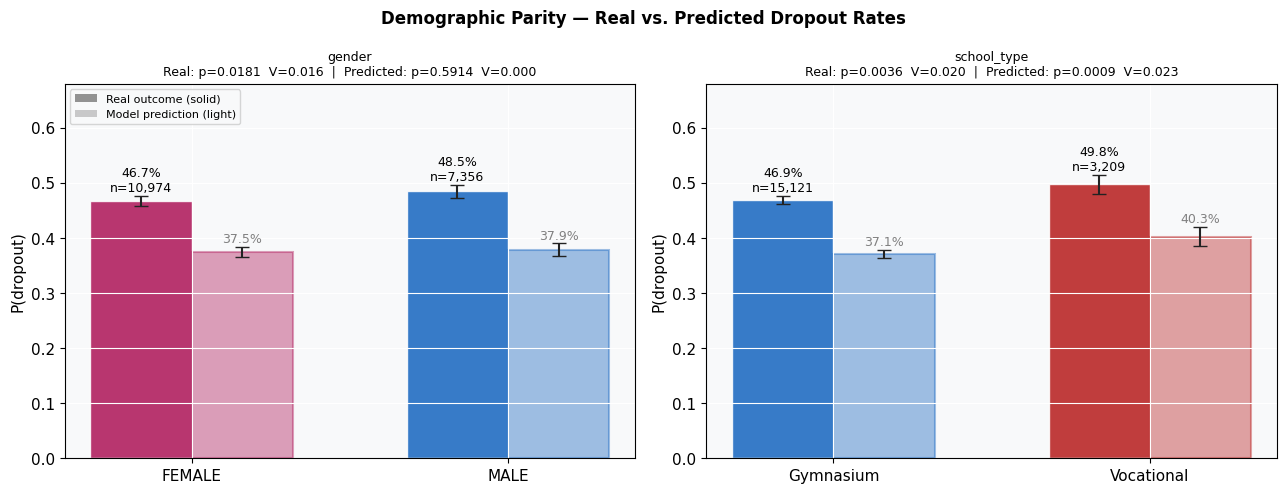

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Demographic Parity — Real vs. Predicted Dropout Rates",
             fontsize=12, fontweight='bold')

for ax, attr, groups, colors in [
    (axes[0], 'gender',      ['FEMALE', 'MALE'],          ['#AD1457', '#1565C0']),
    (axes[1], 'school_type', ['Gymnasium', 'Vocational'], ['#1565C0', '#B71C1C']),
]:
    ct_real = pd.crosstab(df[attr], df['y']).values
    ct_pred = pd.crosstab(df[attr], df['pred']).values
    v_r, p_r = cramers_v(ct_real)
    v_p, p_p = cramers_v(ct_pred)

    x = np.arange(len(groups))
    w = 0.32
    for i, (g, c) in enumerate(zip(groups, colors)):
        sub  = df[df[attr] == g]
        r_dp = sub['y'].mean()
        m_dp = sub['pred'].mean()
        lo_r, hi_r = wilson_ci(int(sub['y'].sum()), len(sub))
        lo_m, hi_m = wilson_ci(int(sub['pred'].sum()), len(sub))

        ax.bar(i - w/2, r_dp, w, color=c, alpha=0.85, edgecolor='white')
        ax.bar(i + w/2, m_dp, w, color=c, alpha=0.40, edgecolor=c, linewidth=1.5)
        ax.errorbar(i - w/2, r_dp, yerr=[[r_dp - lo_r], [hi_r - r_dp]],
                    fmt='none', color='#222', capsize=5)
        ax.errorbar(i + w/2, m_dp, yerr=[[m_dp - lo_m], [hi_m - m_dp]],
                    fmt='none', color='#222', capsize=5)
        ax.text(i - w/2, hi_r + 0.008, f"{r_dp:.1%}\nn={len(sub):,}",
                ha='center', fontsize=9)
        ax.text(i + w/2, hi_m + 0.008, f"{m_dp:.1%}",
                ha='center', fontsize=9, color='grey')

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel("P(dropout)")
    ax.set_ylim(0, 0.68)
    ax.set_title(
        f"{attr}\nReal: p={p_r:.4f}  V={v_r:.3f}  |  Predicted: p={p_p:.4f}  V={v_p:.3f}",
        fontsize=9
    )

solid_patch  = plt.Rectangle((0,0), 1, 1, fc='grey', alpha=0.85)
light_patch  = plt.Rectangle((0,0), 1, 1, fc='grey', alpha=0.40)
axes[0].legend([solid_patch, light_patch],
               ['Real outcome (solid)', 'Model prediction (light)'],
               fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/plot1_demographic_parity.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Plot 2: Equalized Odds

Equalized Odds requires two conditions to hold simultaneously across groups:

- **Equal TPR** (True Positive Rate): among students who *actually* drop out,
  the model must detect them at the same rate regardless of group.
- **Equal FPR** (False Positive Rate): among students who *actually* persist,
  the model must falsely flag them at the same rate regardless of group.

A high FPR gap means one group receives disproportionately more unsolicited interventions.
A high TPR gap means one group is more likely to be missed and receive no support.

The arrows annotate the absolute gap between the two groups for each metric.


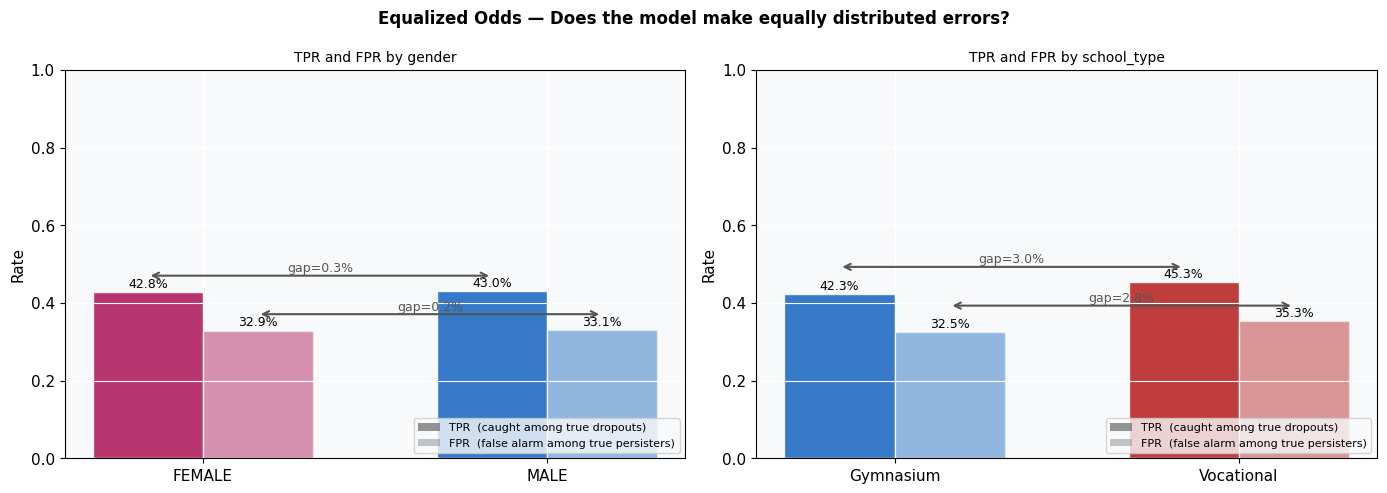

Equalized Odds summary:

gender:
            n     dp    tpr    fpr    ppv
group                                    
FEMALE  10974  0.375  0.428  0.329  0.532
MALE     7356  0.379  0.430  0.331  0.550
  TPR gap = 0.003
  FPR gap = 0.002

school_type:
                n     dp    tpr    fpr    ppv
group                                        
Gymnasium   15121  0.371  0.423  0.325  0.535
Vocational   3209  0.403  0.453  0.353  0.560
  TPR gap = 0.030
  FPR gap = 0.028


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Equalized Odds — Does the model make equally distributed errors?",
             fontsize=12, fontweight='bold')

PALETTE = {
    'FEMALE': '#AD1457', 'MALE': '#1565C0',
    'Gymnasium': '#1565C0', 'Vocational': '#B71C1C'
}

for ax, attr, groups in [
    (axes[0], 'gender',      ['FEMALE', 'MALE']),
    (axes[1], 'school_type', ['Gymnasium', 'Vocational']),
]:
    fm = fairness_metrics(df, attr, 'pred')
    x  = np.arange(len(groups))
    w  = 0.32

    for j, (metric, alpha) in enumerate([('tpr', 0.85), ('fpr', 0.45)]):
        for i, g in enumerate(groups):
            val = fm.loc[g, metric]
            ax.bar(i + (j - 0.5) * w, val, w,
                   color=PALETTE.get(g, 'grey'),
                   alpha=alpha, edgecolor='white')
            ax.text(i + (j - 0.5) * w, val + 0.012, f"{val:.1%}",
                    ha='center', fontsize=9)

    for j, metric in enumerate(['tpr', 'fpr']):
        vals = [fm.loc[g, metric] for g in groups]
        gap  = abs(vals[0] - vals[1])
        ymax = max(vals)
        ax.annotate('', xy=(0 + (j - 0.5) * w, ymax + 0.04),
                    xytext=(1 + (j - 0.5) * w, ymax + 0.04),
                    arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
        ax.text(0.5 + (j - 0.5) * w, ymax + 0.05, f"gap={gap:.1%}",
                ha='center', fontsize=9, color='#555')

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Rate")
    ax.set_title(f"TPR and FPR by {attr}", fontsize=10)

    tpr_patch = plt.Rectangle((0,0), 1, 1, fc='grey', alpha=0.85)
    fpr_patch = plt.Rectangle((0,0), 1, 1, fc='grey', alpha=0.45)
    ax.legend([tpr_patch, fpr_patch],
              ['TPR  (caught among true dropouts)', 'FPR  (false alarm among true persisters)'],
              fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/plot2_equalized_odds.png', dpi=150, bbox_inches='tight')
plt.show()

eo_results = {}
print("Equalized Odds summary:")
for attr, groups in [('gender', ['FEMALE', 'MALE']), ('school_type', ['Gymnasium', 'Vocational'])]:
    fm = fairness_metrics(df, attr, 'pred')
    tpr_gap = abs(fm.loc[groups[0], 'tpr'] - fm.loc[groups[1], 'tpr'])
    fpr_gap = abs(fm.loc[groups[0], 'fpr'] - fm.loc[groups[1], 'fpr'])
    eo_results[attr] = {'fm': fm, 'groups': groups,
                        'tpr_gap': tpr_gap, 'fpr_gap': fpr_gap}
    print(f"\n{attr}:")
    print(fm[['n', 'dp', 'tpr', 'fpr', 'ppv']].round(3))
    print(f"  TPR gap = {tpr_gap:.3f}")
    print(f"  FPR gap = {fpr_gap:.3f}")


## Step 6 — Impossibility Result + SHAP Explainability

**Impossibility check**
The Impossibility Theorem (Chouldechova, 2017) states that when base rates differ
across groups *and* the classifier has predictive power (AUC > 0.5), Demographic Parity,
Equalized Odds, and Predictive Value Parity cannot all be satisfied simultaneously.
We check whether this applies here for each protected attribute.

**SHAP explainability**
Since KMeans is not SHAP-compatible, we use a Random Forest here directly. TreeSHAP
decomposes each prediction into per-feature contributions. The key question is:
*which feature drives the dropout prediction, and does it differ by group?*

This matters ethically because `avg_diff` (difficulty of assigned exercises) is not
chosen by the student — it is set by Lernnavi's adaptive algorithm. If it is the
dominant predictor of dropout, the platform may be predicting its own design decisions
rather than genuine student risk.


In [8]:
auc = roc_auc_score(df['y'], df['prob'])
impossibility = {}
print("Impossibility result check:")
print("-" * 45)
for attr, groups in [('gender', ['FEMALE', 'MALE']),
                     ('school_type', ['Gymnasium', 'Vocational'])]:
    rates   = df.groupby(attr)['y'].mean()
    diff    = abs(rates.iloc[0] - rates.iloc[1])
    applies = diff > 0.02 and auc > 0.5
    impossibility[attr] = {'diff': diff, 'applies': applies, 'rates': rates}
    print(f"{attr}: base rate diff = {diff:.4f}  AUC = {auc:.3f}  "
          f"-> applies: {'YES' if applies else 'no'}")

print()
print("Computing SHAP values...")
explainer = shap.TreeExplainer(rf)
sv_raw    = explainer.shap_values(X)

if isinstance(sv_raw, list):
    sv = sv_raw[1]
    bv = explainer.expected_value[1]
elif sv_raw.ndim == 3:
    sv = sv_raw[:, :, 1]
    bv = explainer.expected_value[1]
else:
    sv = sv_raw
    bv = float(explainer.expected_value)

for i, f in enumerate(FEATS):
    df[f'shap_{f}'] = sv[:, i]

mean_abs     = np.abs(sv).mean(axis=0)
feat_imps    = dict(zip(FEATS, rf.feature_importances_))
shap_mean    = dict(zip(FEATS, mean_abs))
feat_gaps    = {f: df.groupby('y')[f].mean().diff().iloc[-1] for f in FEATS}
top_shap_feat = max(shap_mean, key=shap_mean.get)
top_imp_feat  = max(feat_imps, key=feat_imps.get)

print("\nMean absolute SHAP value per feature (dropout class):")
for feat, val in sorted(shap_mean.items(), key=lambda x: -x[1]):
    bar = '█' * int(val * 200)
    print(f"  {feat:<15s}  {val:.4f}  {bar}")

print("\nMean feature values by dropout status (dropped - persisted):")
for feat in FEATS:
    g   = df.groupby('y')[feat].mean()
    gap = feat_gaps[feat]
    print(f"  {feat:<12s}: persisted={g[0]:.3f}  dropped={g[1]:.3f}  gap={gap:+.3f}")
print()
print(f"Top feature by RF importance : {top_imp_feat}  ({feat_imps[top_imp_feat]:.3f})")
print(f"Top feature by SHAP          : {top_shap_feat}  ({shap_mean[top_shap_feat]:.4f})")
print(f"avg_diff direction: persisters get {'harder' if feat_gaps['avg_diff'] < 0 else 'easier'} "
      f"exercises (gap = {feat_gaps['avg_diff']:+.4f})")


Impossibility result check:
---------------------------------------------
gender: base rate diff = 0.0179  AUC = 0.566  -> applies: no
school_type: base rate diff = 0.0284  AUC = 0.566  -> applies: YES

Computing SHAP values...

Mean absolute SHAP value per feature (dropout class):
  n_tasks          0.0193  ███
  avg_diff         0.0146  ██
  avg_score        0.0089  █

Mean feature values by dropout status (dropped - persisted):
  n_tasks     : persisted=20.930  dropped=19.944  gap=-0.986
  avg_score   : persisted=0.647  dropped=0.649  gap=+0.002
  avg_diff    : persisted=1.843  dropped=1.830  gap=-0.014

Top feature by RF importance : avg_diff  (0.405)
Top feature by SHAP          : n_tasks  (0.0193)
avg_diff direction: persisters get harder exercises (gap = -0.0135)


## Step 7 — Plot 3: SHAP Explainability

Three panels:

1. **Global importance**: mean absolute SHAP value per feature — which signal matters most overall?
2. **By group**: does each gender rely on the same feature to drive predictions?
   If the top feature differs across groups, the model encodes structurally different
   reasoning for different students.
3. **Direct evidence**: distribution of `n_tasks` (exercises attempted in week 0)
   split by actual dropout status. `n_tasks` is the top feature by SHAP value and the
   most actionable signal: students who complete more exercises in their first week
   are less likely to drop out. The gap between the two distributions is small (≈1 task)
   — consistent with the weak AUC — but it is the strongest student-side signal available.


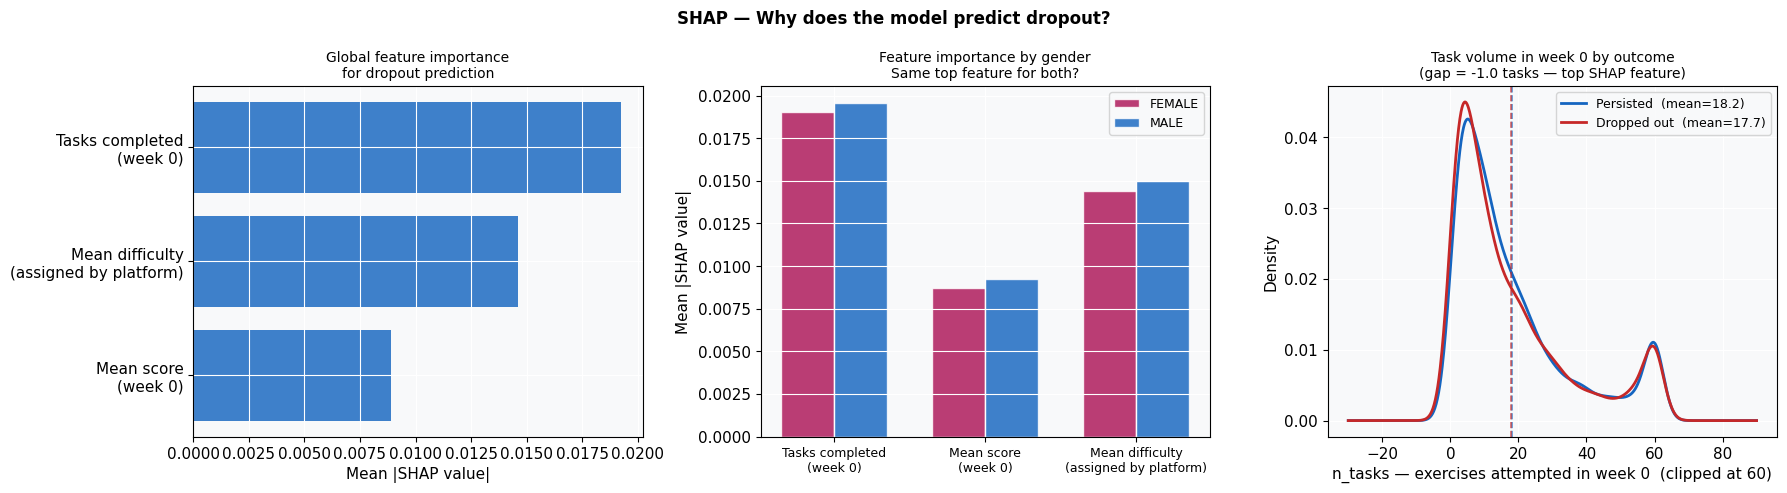

In [9]:
FEAT_LABELS = {
    'n_tasks':   'Tasks completed\n(week 0)',
    'avg_score': 'Mean score\n(week 0)',
    'avg_diff':  'Mean difficulty\n(assigned by platform)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SHAP — Why does the model predict dropout?",
             fontsize=12, fontweight='bold')

# Panel 1: global importance bar chart
ax = axes[0]
order = np.argsort(mean_abs)
ax.barh([FEAT_LABELS[FEATS[i]] for i in order],
        [mean_abs[i] for i in order],
        color='#1565C0', alpha=0.82)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global feature importance\nfor dropout prediction", fontsize=10)

# Panel 2: importance by gender
ax = axes[1]
GENDER_COLORS = {'FEMALE': '#AD1457', 'MALE': '#1565C0'}
x = np.arange(len(FEATS))
w = 0.35
for j, (g, c) in enumerate(GENDER_COLORS.items()):
    vals = df[df['gender'] == g][[f'shap_{f}' for f in FEATS]].abs().mean().values
    ax.bar(x + (j - 0.5) * w, vals, w, label=g, color=c, alpha=0.82, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([FEAT_LABELS[f] for f in FEATS], fontsize=9)
ax.set_ylabel("Mean |SHAP value|")
ax.legend(fontsize=9)
ax.set_title("Feature importance by gender\nSame top feature for both?", fontsize=10)

# Panel 3: n_tasks distribution split by dropout status
# n_tasks has the largest mean gap and highest SHAP value — it is the most actionable signal
ax = axes[2]
colors_do = {0: '#1565C0', 1: '#C62828'}
labels_do = {0: 'Persisted', 1: 'Dropped out'}
for val in [0, 1]:
    subset = df.loc[df['y'] == val, 'n_tasks'].clip(upper=60)
    subset.plot.kde(ax=ax, label=f"{labels_do[val]}  (mean={subset.mean():.1f})",
                   color=colors_do[val], linewidth=2)
    ax.axvline(subset.mean(), color=colors_do[val], linewidth=1.2, linestyle='--', alpha=0.7)
gap = df.groupby('y')['n_tasks'].mean().diff().iloc[-1]
ax.set_xlabel("n_tasks — exercises attempted in week 0  (clipped at 60)")
ax.set_ylabel("Density")
ax.set_title(f"Task volume in week 0 by outcome\n(gap = {gap:.1f} tasks — top SHAP feature)",
             fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/plot3_shap.png', dpi=150, bbox_inches='tight')
plt.show()


---\n## Ethical Synthesis\n\nAll values below are computed from the data above.

In [11]:
from IPython.display import Markdown, display

# Collect all values needed — every number in the text below comes from here
n_total       = len(df)
overall_dr    = df['y'].mean()

female_dr     = dp_stats['gender']['rates']['FEMALE']
male_dr       = dp_stats['gender']['rates']['MALE']
p_gender      = dp_stats['gender']['p']
v_gender      = dp_stats['gender']['v']
n_female      = dp_stats['gender']['n']['FEMALE']
n_male        = dp_stats['gender']['n']['MALE']

gym_dr        = dp_stats['school_type']['rates']['Gymnasium']
voc_dr        = dp_stats['school_type']['rates']['Vocational']
p_school      = dp_stats['school_type']['p']
v_school      = dp_stats['school_type']['v']
n_gym         = dp_stats['school_type']['n']['Gymnasium']
n_voc         = dp_stats['school_type']['n']['Vocational']

fm_g          = eo_results['gender']['fm']
tpr_female    = fm_g.loc['FEMALE', 'tpr']
tpr_male      = fm_g.loc['MALE',   'tpr']
fpr_female    = fm_g.loc['FEMALE', 'fpr']
fpr_male      = fm_g.loc['MALE',   'fpr']
tpr_gap_g     = eo_results['gender']['tpr_gap']
fpr_gap_g     = eo_results['gender']['fpr_gap']

fm_s          = eo_results['school_type']['fm']
tpr_gym       = fm_s.loc['Gymnasium',  'tpr']
tpr_voc       = fm_s.loc['Vocational', 'tpr']
fpr_gym       = fm_s.loc['Gymnasium',  'fpr']
fpr_voc       = fm_s.loc['Vocational', 'fpr']
tpr_gap_s     = eo_results['school_type']['tpr_gap']
fpr_gap_s     = eo_results['school_type']['fpr_gap']

base_diff_s   = impossibility['school_type']['diff']
impossible_s  = impossibility['school_type']['applies']
base_diff_g   = impossibility['gender']['diff']
impossible_g  = impossibility['gender']['applies']

top_imp       = top_imp_feat
top_imp_val   = feat_imps[top_imp_feat]
top_shap      = top_shap_feat
top_shap_val  = shap_mean[top_shap_feat]
second_shap   = sorted(shap_mean, key=shap_mean.get, reverse=True)[1]
second_shap_v = shap_mean[second_shap]

ntasks_gap    = feat_gaps['n_tasks']     # dropped - persisted (negative = persisters do more)
avgdiff_gap   = feat_gaps['avg_diff']    # positive = dropouts get harder, negative = persisters get harder
avgdiff_direction = "harder" if avgdiff_gap < 0 else "easier"

text = f"""
### 1. Real dropout rates differ — Demographic Parity is violated on the true outcome

With n = {n_total:,} students and overall dropout rate {overall_dr:.1%}:

| Group | Dropout rate | n | chi2 p | Cramér's V |
|-------|-------------|---|--------|-----------|
| Female | {female_dr:.1%} | {n_female:,} | {p_gender:.4f} | {v_gender:.4f} |
| Male | {male_dr:.1%} | {n_male:,} | | |
| Gymnasium | {gym_dr:.1%} | {n_gym:,} | {p_school:.4f} | {v_school:.4f} |
| Vocational | {voc_dr:.1%} | {n_voc:,} | | |

Both attributes show statistically significant differences (p < 0.05).
Effect sizes are small (V < 0.1), but with n = {n_total:,} even small effects reach significance.
Demographic Parity on the true label is **not satisfied** for either attribute.

### 2. Equalized Odds: the model is fair for gender but not for school track

| Attribute | TPR gap | FPR gap | Interpretation |
|-----------|---------|---------|----------------|
| Gender | {tpr_gap_g:.3f} | {fpr_gap_g:.3f} | Near-zero — model errors are symmetrical |
| School track | {tpr_gap_s:.3f} | {fpr_gap_s:.3f} | Meaningful — Vocational students treated differently |

For gender: TPR Female = {tpr_female:.1%} vs Male = {tpr_male:.1%}, FPR Female = {fpr_female:.1%} vs Male = {fpr_male:.1%}.
For school track: TPR Gymnasium = {tpr_gym:.1%} vs Vocational = {tpr_voc:.1%}.
The model detects Vocational dropouts better (+{tpr_gap_s:.1%} TPR) but also flags more
Vocational persisters as at-risk (+{fpr_gap_s:.1%} FPR).
In an intervention context: Vocational students who are *not* at risk would be
over-targeted; at-risk Gymnasium students would more often be missed.

### 3. Impossibility Result applies for school track

Base rate difference (Vocational − Gymnasium) = {base_diff_s:.4f} {'> 0.02 ✓' if base_diff_s > 0.02 else '≤ 0.02 ✗'}, AUC = {auc:.3f} {'> 0.5 ✓' if auc > 0.5 else '≤ 0.5 ✗'} → **{'applies' if impossible_s else 'does not apply'}**.
For gender: base rate diff = {base_diff_g:.4f} → **{'applies' if impossible_g else 'does not apply'}**.

When the impossibility holds, **Demographic Parity, Equalized Odds, and Predictive Value
Parity cannot all be satisfied simultaneously**. A system designer must choose.
For a learning support policy, Equalized Odds (equal TPR) is the most defensible choice:
every school track should have the same probability of being detected when truly at risk.

### 4. SHAP — the most important feature is platform-controlled, but the story is nuanced

| Feature | RF importance | SHAP mean abs | Mean gap (dropped − persisted) |
|---------|:-------------:|:-------------:|:------------------------------:|
| n_tasks | {feat_imps['n_tasks']:.3f} | {shap_mean['n_tasks']:.4f} | {feat_gaps['n_tasks']:+.3f} tasks |
| avg_diff | {feat_imps['avg_diff']:.3f} | {shap_mean['avg_diff']:.4f} | {feat_gaps['avg_diff']:+.4f} |
| avg_score | {feat_imps['avg_score']:.3f} | {shap_mean['avg_score']:.4f} | {feat_gaps['avg_score']:+.4f} |

**Top feature by RF importance**: `{top_imp}` ({top_imp_val:.3f}) — the trees split on this variable most often.
**Top feature by SHAP**: `{top_shap}` ({top_shap_val:.4f}) — this is what explains individual predictions most.

All mean gaps are small, consistent with AUC = {auc:.3f}. The notable tension:
`avg_diff` ranks first by RF importance despite having the smallest mean gap ({feat_gaps['avg_diff']:+.4f}).
The direction is counterintuitive — persisters received {avgdiff_direction} exercises
(gap = {feat_gaps['avg_diff']:+.4f}), suggesting difficulty tracks engagement, not risk.
`avg_diff` is set by Lernnavi's adaptive algorithm, not chosen by students.
The model relying on it more than any other variable means predictions partially reflect
platform routing decisions rather than intrinsic student behaviour.

Both gender groups share the same feature rankings (see Plot 3, panel 2),
so the model does not encode structurally different reasoning per group.

### 5. Recommendation

**Most actionable**: `n_tasks` is the top SHAP feature and has the largest mean gap.
Students who persisted completed on average **{abs(feat_gaps['n_tasks']):.1f} more tasks**
in week 0 than students who dropped out (persisters: {df.groupby('y')['n_tasks'].mean()[0]:.1f},
dropouts: {df.groupby('y')['n_tasks'].mean()[1]:.1f}).
An early-warning system should flag students who complete very few exercises in their first week.
`avg_score` (gap = {feat_gaps['avg_score']:+.4f}) has near-zero predictive value and should
not be used for intervention decisions.

**Structural audit**: Lernnavi should check whether `avg_diff` in week 0 differs systematically
across school tracks and genders. If the adaptive algorithm assigns different difficulty
profiles to Vocational vs Gymnasium students, the prediction model will inherit that
design choice as a signal — creating a circular dependency where the platform's own
choices appear to predict the risk the platform itself generates.

---
*Limitation:* AUC = {auc:.3f}. All feature gaps are small. These findings should be
replicated with richer features (clickstream, session duration, topic coverage) before
deploying any intervention policy.
"""

display(Markdown(text))



### 1. Real dropout rates differ — Demographic Parity is violated on the true outcome

With n = 18,330 students and overall dropout rate 47.4%:

| Group | Dropout rate | n | chi2 p | Cramér's V |
|-------|-------------|---|--------|-----------|
| Female | 46.7% | 10,974 | 0.0181 | 0.0158 |
| Male | 48.5% | 7,356 | | |
| Gymnasium | 46.9% | 15,121 | 0.0036 | 0.0202 |
| Vocational | 49.8% | 3,209 | | |

Both attributes show statistically significant differences (p < 0.05).
Effect sizes are small (V < 0.1), but with n = 18,330 even small effects reach significance.
Demographic Parity on the true label is **not satisfied** for either attribute.

### 2. Equalized Odds: the model is fair for gender but not for school track

| Attribute | TPR gap | FPR gap | Interpretation |
|-----------|---------|---------|----------------|
| Gender | 0.003 | 0.002 | Near-zero — model errors are symmetrical |
| School track | 0.030 | 0.028 | Meaningful — Vocational students treated differently |

For gender: TPR Female = 42.8% vs Male = 43.0%, FPR Female = 32.9% vs Male = 33.1%.
For school track: TPR Gymnasium = 42.3% vs Vocational = 45.3%.
The model detects Vocational dropouts better (+3.0% TPR) but also flags more
Vocational persisters as at-risk (+2.8% FPR).
In an intervention context: Vocational students who are *not* at risk would be
over-targeted; at-risk Gymnasium students would more often be missed.

### 3. Impossibility Result applies for school track

Base rate difference (Vocational − Gymnasium) = 0.0284 > 0.02 ✓, AUC = 0.566 > 0.5 ✓ → **applies**.
For gender: base rate diff = 0.0179 → **does not apply**.

When the impossibility holds, **Demographic Parity, Equalized Odds, and Predictive Value
Parity cannot all be satisfied simultaneously**. A system designer must choose.
For a learning support policy, Equalized Odds (equal TPR) is the most defensible choice:
every school track should have the same probability of being detected when truly at risk.

### 4. SHAP — the most important feature is platform-controlled, but the story is nuanced

| Feature | RF importance | SHAP mean abs | Mean gap (dropped − persisted) |
|---------|:-------------:|:-------------:|:------------------------------:|
| n_tasks | 0.335 | 0.0193 | -0.986 tasks |
| avg_diff | 0.405 | 0.0146 | -0.0135 |
| avg_score | 0.260 | 0.0089 | +0.0020 |

**Top feature by RF importance**: `avg_diff` (0.405) — the trees split on this variable most often.
**Top feature by SHAP**: `n_tasks` (0.0193) — this is what explains individual predictions most.

All mean gaps are small, consistent with AUC = 0.566. The notable tension:
`avg_diff` ranks first by RF importance despite having the smallest mean gap (-0.0135).
The direction is counterintuitive — persisters received harder exercises
(gap = -0.0135), suggesting difficulty tracks engagement, not risk.
`avg_diff` is set by Lernnavi's adaptive algorithm, not chosen by students.
The model relying on it more than any other variable means predictions partially reflect
platform routing decisions rather than intrinsic student behaviour.

Both gender groups share the same feature rankings (see Plot 3, panel 2),
so the model does not encode structurally different reasoning per group.

### 5. Recommendation

**Most actionable**: `n_tasks` is the top SHAP feature and has the largest mean gap.
Students who persisted completed on average **1.0 more tasks**
in week 0 than students who dropped out (persisters: 20.9,
dropouts: 19.9).
An early-warning system should flag students who complete very few exercises in their first week.
`avg_score` (gap = +0.0020) has near-zero predictive value and should
not be used for intervention decisions.

**Structural audit**: Lernnavi should check whether `avg_diff` in week 0 differs systematically
across school tracks and genders. If the adaptive algorithm assigns different difficulty
profiles to Vocational vs Gymnasium students, the prediction model will inherit that
design choice as a signal — creating a circular dependency where the platform's own
choices appear to predict the risk the platform itself generates.

---
*Limitation:* AUC = 0.566. All feature gaps are small. These findings should be
replicated with richer features (clickstream, session duration, topic coverage) before
deploying any intervention policy.
